In [1]:
import os
from pathlib import Path
import pickle
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from glmhmm import *
from my_fun import fig_size, save_notebook_files

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [3]:
# Plotting style
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'
sns.set_style('ticks')
sns.set_context('notebook')

In [4]:
df = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session=f'glmhmm/TEST/2s_3cov')
df_null = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/1s_null')

# Mean groups 2-4

Covariate 0: t=1.530, p=0.1392
Covariate 1: t=0.614, p=0.5453
Covariate 2: t=-8.093, p=0.0000


<Axes: title={'center': 'GLM-HMM kernel'}, ylabel='Weight'>

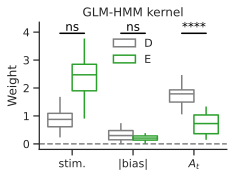

In [17]:
data = results_2_df(df)
figsize = fig_size(n_cols=2)
plot_paired_boxplot_GLMHMM_kernel(data, figsize=figsize, loc='upper center',  bbox_to_anchor=(0.5, 0.95))
# plt.title('2 states 3 covariates')

array([[0.98100712, 0.01899288],
       [0.01432419, 0.98567581]])

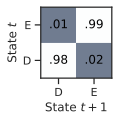

In [6]:
trans_mat = get_str_mat(df, col_name='TransMat')
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
plot_trans_mat(trans_mat, figsize=figsize)

State D occupancy: 0.37
State E occupancy: 0.63


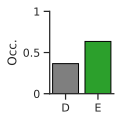

In [7]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
plot_occupancy(df, figsize=figsize)

0.44 ± 0.35 LL (bits/trial)


([], [])

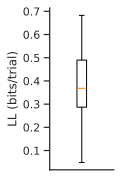

In [8]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[1])
plt.figure(figsize=figsize, constrained_layout=True)
ll_null = df_null.LogLikelihood.unique()
n_trials = df_null.groupby('Subject').size()
ll = df.LogLikelihood.unique()
plot_ll(ll, n_trials, ll_null=ll_null, to_bits=True, figsize=figsize)
plt.xlabel('')
plt.xticks([], [])

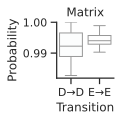

In [9]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
plot_trans_mat_box_plots(trans_mat, figsize=figsize)

State
Disengaged    0.36521
Engaged       0.63479
Name: Occupancy, dtype: float64


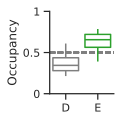

In [18]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
_ = plot_occupancy_boxplot(df, figsize=figsize)

# Group 2

Mice: [325 326 327 329 330 332 333 335 337]
Covariate 0: t=5.868, p=0.0004
Covariate 1: t=-0.790, p=0.4521
Covariate 2: t=-4.847, p=0.0013
(-0.1495818597, 3.2908009134)


(-0.3, 6.0)

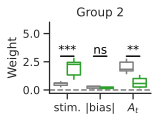

In [28]:
experiment = '2AFC_2'
figsize = fig_size(n_cols=3)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()
print(plt.gca().get_ylim())
plt.ylim(-0.3, 6)

# Group 3

Mice: [419 420 422 616 617 619 623]
Covariate 0: t=1.119, p=0.3061
Covariate 1: t=0.783, p=0.4636
Covariate 2: t=-5.614, p=0.0014
(-0.133804188525, 2.94369214755)


(-0.3, 6.0)

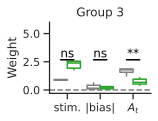

In [29]:
experiment = '2AFC_3'
figsize = fig_size(n_cols=3)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()
print(plt.gca().get_ylim())
plt.ylim(-0.3, 6)

# Group 4

Mice: [561 807 820 821 873 875 907 909 911]
Covariate 0: t=6.821, p=0.0001
Covariate 1: t=0.317, p=0.7592
Covariate 2: t=-5.304, p=0.0007
(-0.27082578915000005, 5.958167361300001)


(-0.3, 6.0)

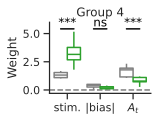

In [30]:
experiment = '2AFC_4'
figsize = fig_size(n_cols=3)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()
print(plt.gca().get_ylim())
plt.ylim(-0.3, 6)

# Group 6
Drug

## Rest
No injection sessions (no saline nor drug) were fitted separately

In [5]:
df_rest = glue_groups(experiments=['2AFC_6'], path_session=f'glmhmm/pharma/rest')

Covariate 0: t=4.107, p=0.0021
Covariate 1: t=-0.101, p=0.9216
Covariate 2: t=-2.441, p=0.0348
(-1.079033888625, 23.73874554975)


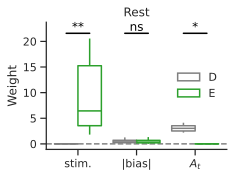

In [52]:
data_rest = results_2_df(df_rest)
figsize = fig_size(n_cols=2)
plot_paired_boxplot_GLMHMM_kernel(data_rest, figsize=figsize)
plt.title('Rest')
print(plt.gca().get_ylim())

array([[0.59671417, 0.40328583],
       [0.34698915, 0.65301085]])

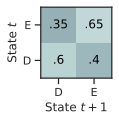

In [53]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
trans_mat_rest = get_str_mat(df_rest, col_name='TransMat')
plot_trans_mat(trans_mat_rest, figsize=figsize)

State D occupancy: 0.40
State E occupancy: 0.60


Text(0, 0.5, 'Occupancy')

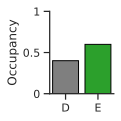

In [10]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
plot_occupancy(df_rest, figsize=figsize)
plt.ylabel('Occupancy')

State
Disengaged    0.400835
Engaged       0.599165
Name: Occupancy, dtype: float64


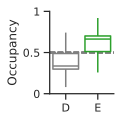

In [9]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
_ = plot_occupancy_boxplot(df_rest, figsize=figsize)

## Saline
Paired saline sessions were fitted separately

In [12]:
df_saline = glue_groups(experiments=['2AFC_6'], path_session=f'glmhmm/pharma/saline')

Covariate 0: t=3.564, p=0.0061
Covariate 1: t=-1.931, p=0.0855
Covariate 2: t=-3.097, p=0.0128
(-0.698301121275, 3.47420689605)


(-0.7, 4.6)

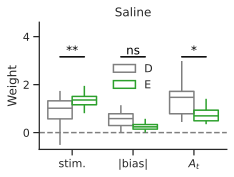

In [60]:
data_saline = results_2_df(df_saline)
figsize = fig_size(n_cols=2)
plot_paired_boxplot_GLMHMM_kernel(data_saline, figsize=figsize, loc='upper center', bbox_to_anchor=(0.5, 0.75))
plt.title('Saline')
print(plt.gca().get_ylim())
plt.ylim(-0.7, 4.6)

array([[0.99469961, 0.00530039],
       [0.00430096, 0.99569904]])

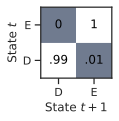

In [25]:
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[0]/2)
trans_mat_saline = get_str_mat(df_saline, col_name='TransMat')
plot_trans_mat(trans_mat_saline, figsize=figsize)

State D occupancy: 0.44
State E occupancy: 0.56


Text(0, 0.5, 'Occupancy')

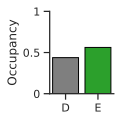

In [17]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
plot_occupancy(df_saline, figsize=figsize)
plt.ylabel('Occupancy')

State
Disengaged    0.437926
Engaged       0.562074
Name: Occupancy, dtype: float64


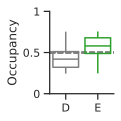

In [18]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
df_occ_saline = plot_occupancy_boxplot(df_saline, figsize=figsize)

## Drug
Paired drug sessions were fitted separately

In [19]:
df_drug = glue_groups(experiments=['2AFC_6'], path_session=f'glmhmm/pharma/drug')

Covariate 0: t=3.841, p=0.0040
Covariate 1: t=-1.907, p=0.0888
Covariate 2: t=-3.264, p=0.0098
(-0.21068629732500002, 4.6350985411500005)


(-0.7, 4.6)

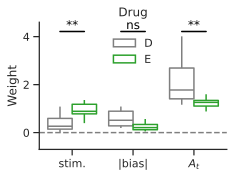

In [57]:
data_drug = results_2_df(df_drug)
figsize = fig_size(n_cols=2)
plot_paired_boxplot_GLMHMM_kernel(data_drug, figsize=figsize, loc='upper center', bbox_to_anchor=(0.5, 0.95))
plt.title('Drug')
print(plt.gca().get_ylim())
plt.ylim(-0.7, 4.6)

array([[0.99478332, 0.00521668],
       [0.00336264, 0.99663736]])

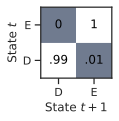

In [24]:
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[0]/2)
trans_mat_drug = get_str_mat(df_drug, col_name='TransMat')
plot_trans_mat(trans_mat_drug, figsize=figsize)

State D occupancy: 0.41
State E occupancy: 0.59


Text(0, 0.5, 'Occupancy')

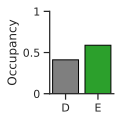

In [22]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
plot_occupancy(df_drug, figsize=figsize)
plt.ylabel('Occupancy')

State
Disengaged    0.411081
Engaged       0.588919
Name: Occupancy, dtype: float64


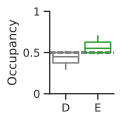

In [23]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
df_occ_drug = plot_occupancy_boxplot(df_drug, figsize=figsize)

## Combining saline and drug sessions fitted separately
Compare their weights between drug conditions for each state

In [28]:
# Combine saline and drug data DataFrames
data_saline['Drug'] = 0
data_drug['Drug'] = 1
data = pd.concat([data_saline, data_drug], ignore_index=True)

### Disengaged

Covariate 0: t=-7.123, p=0.0001
Covariate 1: t=0.273, p=0.7911
Covariate 2: t=2.995, p=0.0151


(-0.7, 4.6)

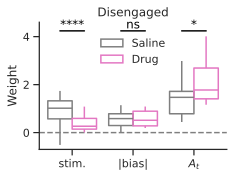

In [64]:
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Label=='Disengaged'], drug=True, figsize=figsize, loc='upper center', bbox_to_anchor=(0.5, 0.95))
plt.title('Disengaged')
plt.ylim(-0.7, 4.6)

### Engaged

Covariate 0: t=-1.781, p=0.1085
Covariate 1: t=-0.527, p=0.6111
Covariate 2: t=2.945, p=0.0164
(-0.102257178975, 2.2538512674609192)


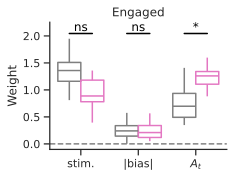

In [66]:
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Label=='Engaged'], drug=True, figsize=figsize)
plt.title('Engaged')
ax.get_legend().remove()
print(plt.gca().get_ylim())

## Paired sessions
Saline-drug session pairs were fitted together

In [33]:
df_paired = glue_groups(experiments=['2AFC_6'], path_session=f'glmhmm/pharma/paired_sessions')

Covariate 0: t=5.472, p=0.0004
Covariate 1: t=-1.410, p=0.1922
Covariate 2: t=-4.005, p=0.0031
(-0.229279018, 3.9755356300000004)


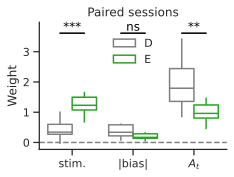

In [51]:
data_paired = results_2_df(df_paired)
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data_paired, drug=False, figsize=figsize, loc='upper center', bbox_to_anchor=(0.5, 0.95))
plt.title('Paired sessions')
print(plt.gca().get_ylim())

array([[0.99514834, 0.00485166],
       [0.0031643 , 0.9968357 ]])

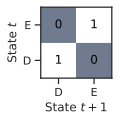

In [65]:
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[0]/2)
trans_mat_paired = get_str_mat(df_paired, col_name='TransMat')
plot_trans_mat(trans_mat_paired, figsize=figsize)

State
Disengaged    0.250981
Engaged       0.749019
Name: Occupancy, dtype: float64
State
Disengaged    0.623003
Engaged       0.376997
Name: Occupancy, dtype: float64


Text(0.5, 1.0, 'Drug')

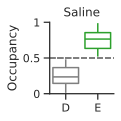

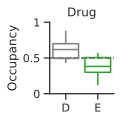

In [36]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
df_occ_saline = plot_occupancy_boxplot(df_paired[df_paired.Drug==0], figsize=figsize)
plt.title('Saline')
df_occ_drug = plot_occupancy_boxplot(df_paired[df_paired.Drug==1], figsize=figsize)
plt.title('Drug')

t=6.299, p=0.0001


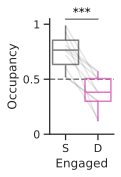

In [44]:
# Combine occupancy dataframes by state. So one df_engaged and one df_disengaged
df_occ_saline['Drug'] = 0
df_occ_drug['Drug'] = 1
df_occ = pd.concat([df_occ_saline, df_occ_drug], ignore_index=True)
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[1])
plt.figure(figsize=figsize, constrained_layout=True)

# Engaged
y = 'Engaged'
plt.axhline(0.5, color='tab:gray', linestyle='--')
sns.boxplot(data=df_occ, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False, showcaps=False, fill=False)
sns.lineplot(data=df_occ, x='Drug', y='Engaged', units='Subject', estimator=None, alpha=0.1, legend=False, color='k')

plt.xticks([0, 1], ['S','D'])
plt.yticks([0, 0.5, 1], ['0', '0.5', '1'])
plt.ylim(0, 1.05)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
p_saline = df_occ[df_occ.Drug==0]['Engaged']
p_drug = df_occ[df_occ.Drug==1]['Engaged']
t_stat, p_val = ttest_rel(p_saline, p_drug)
print(f't={t_stat:.3f}, p={p_val:.4f}')
add_star_between(p_val)

# Save all notebook's figures

In [49]:
# Whole notebook outputs (no input or prompt, only Markdown and figures)
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt  # As HTML
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt  # As PDF

# Export all figures
save_notebook_files(notebook_path='notebook_full_model.ipynb')

Saved 29 images to notebook_full_model_files/
